<a href="https://colab.research.google.com/github/LourdesBranchi/camus-lv-segmentation/blob/main/notebooks/02_train_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Entrenamiento en Google Colab — CAMUS Segmentación

Este notebook entrena los dos modelos y genera los resultados comparativos.

## Verificar GPU

In [ ]:
import torch
print(f'GPU disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU disponible: True
GPU: Tesla T4
Memoria: 15.6 GB


## Montar Drive y definir DRIVE_DIR

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
DRIVE_DIR = '/content/drive/MyDrive/CEIA - UBA/VPCII/TP Final'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Checkpoints se guardarán en: {DRIVE_DIR}')

Checkpoints se guardarán en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final


## Clonar repositorio

In [3]:
%cd /content
!rm -rf /content/camus-lv-segmentation
!git clone https://github.com/LourdesBranchi/camus-lv-segmentation.git
%cd /content/camus-lv-segmentation
!pip install -r requirements.txt -q
print("Listo")

/content
Cloning into 'camus-lv-segmentation'...
remote: Enumerating objects: 69, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 69 (delta 29), reused 40 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (69/69), 1.40 MiB | 4.55 MiB/s, done.
Resolving deltas: 100% (29/29), done.
/content/camus-lv-segmentation
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 120.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.6 MB/s eta 0:00:00
Listo


In [4]:
# Agregar src al path
import sys
sys.path.insert(0, '/content/camus-lv-segmentation/src')

## Configurar Kaggle desde secret y descargar dataset

In [6]:
from google.colab import userdata
import os, json

kaggle_token = userdata.get('KAGGLE_API_TOKEN')
os.environ['KAGGLE_CONFIG_DIR'] = '/root/.kaggle'
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_token)
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d shoybhasan/camus-human-heart-data -q
!unzip -q camus-human-heart-data.zip -d /content/dataset_raw
!rm camus-human-heart-data.zip
print('Dataset descargado.')

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
Dataset descargado.


In [7]:
from abc import ABCMeta
# Descomprimir dataset interno y definir DATA_ROOT
import zipfile, os

inner = '/content/dataset_raw/download'
if os.path.exists(inner):
    with zipfile.ZipFile(inner, 'r') as z:
      z.extractall('/content/datos_corazon')
    print('Dataset listo.')
else:
    print('Buscando archivo comprimido interno:')
    !find /content/dataset_raw -name '*.zip' -o -name 'download'

DATA_ROOT = '/content/datos_corazon/database_nifti'
print(f'DATA_ROOT = {DATA_ROOT}')
!ls {DATA_ROOT} | head -5

Dataset listo.
DATA_ROOT = /content/datos_corazon/database_nifti
patient0001
patient0002
patient0003
patient0004
patient0005


## EDA rápido

Pacientes encontrados: 500
Imágenes totales:      2000

División de pacientes:
  Train: 350 pacientes
  Val:   75 pacientes
  Test:  75 pacientes

Pares imagen/máscara:
  Train: 1400
  Val:   300
  Test:  300
Batch imágenes: torch.Size([8, 1, 256, 256])  dtype=torch.float32
Batch máscaras: torch.Size([8, 256, 256])  clases=[0, 1, 2, 3]


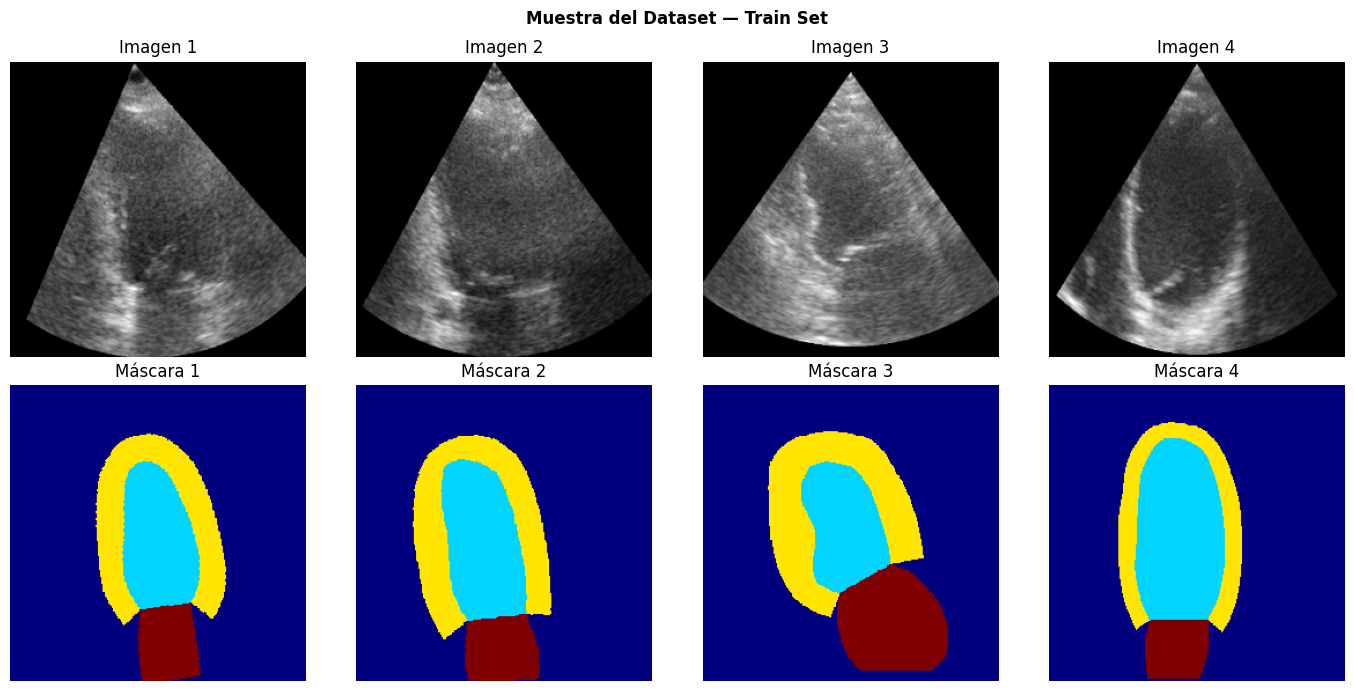

In [8]:
from dataset import prepare_dataset
import matplotlib.pyplot as plt
import numpy as np

loaders = prepare_dataset(
    data_root=DATA_ROOT,
    batch_size=8,
    num_workers=2,
)

imgs, masks = next(iter(loaders['train']))
print(f'Batch imágenes: {imgs.shape}  dtype={imgs.dtype}')
print(f'Batch máscaras: {masks.shape}  clases={masks.unique().tolist()}')

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    axes[0, i].imshow(imgs[i, 0].numpy(), cmap='gray')
    axes[0, i].set_title(f'Imagen {i+1}'); axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].numpy(), cmap='jet', vmin=0, vmax=3)
    axes[1, i].set_title(f'Máscara {i+1}'); axes[1, i].axis('off')
plt.suptitle('Muestra del Dataset — Train Set', fontweight='bold')
plt.tight_layout()
plt.show()

## Entrenar Modelo 1: U-Net + ResNet34

In [9]:
from train import train, DEFAULT_CONFIG

config_unet = {**DEFAULT_CONFIG,
    'model':      'unet',
    'encoder':    'resnet34',
    'epochs':     50,
    'batch_size': 8,
    'lr':         1e-4,
    'patience':   10,
    'data_root':  DATA_ROOT,
    'save_dir':   DRIVE_DIR,
    'device':     'cuda',
}

history_unet = train(config_unet)

Modelo:   unet + resnet34
Device:   cuda
Épocas:   50
Batch:    8
LR:       0.0001

Cargando dataset...
Pacientes encontrados: 500
Imágenes totales:      2000

División de pacientes:
  Train: 350 pacientes
  Val:   75 pacientes
  Test:  75 pacientes

Pares imagen/máscara:
  Train: 1400
  Val:   300
  Test:  300

Creando modelo...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

U-Net (resnet34, ImageNet) — 24.4M parámetros

Entrenando por 50 épocas...

Época [  1/50] (39s) lr=1.00e-04
  Train  loss=0.5874  dice=0.6670  [LV=0.780 MYO=0.586 LA=0.635]
  Val    loss=0.3089  dice=0.8484  [LV=0.898 MYO=0.815 LA=0.832]
  ✓ Mejor modelo guardado (val_dice=0.8484)

Época [  2/50] (38s) lr=1.00e-04
  Train  loss=0.2377  dice=0.8555  [LV=0.902 MYO=0.803 LA=0.861]
  Val    loss=0.1738  dice=0.8868  [LV=0.923 MYO=0.846 LA=0.892]
  ✓ Mejor modelo guardado (val_dice=0.8868)

Época [  3/50] (46s) lr=1.00e-04
  Train  loss=0.1613  dice=0.8775  [LV=0.916 MYO=0.834 LA=0.883]
  Val    loss=0.1403  dice=0.8891  [LV=0.921 MYO=0.846 LA=0.900]
  ✓ Mejor modelo guardado (val_dice=0.8891)

Época [  4/50] (45s) lr=1.00e-04
  Train  loss=0.1324  dice=0.8874  [LV=0.924 MYO=0.845 LA=0.893]
  Val    loss=0.1186  dice=0.8968  [LV=0.929 MYO=0.865 LA=0.896]
  ✓ Mejor modelo guardado (val_dice=0.8968)

Época [  5/50] (45s) lr=1.00e-04
  Train  loss=0.1169  dice=0.8938  [LV=0.929 MYO=0.856 LA=0

In [10]:
# Guardar history_unet como JSON en Drive
import json

unet_json_path = f'{DRIVE_DIR}/history_unet_resnet34.json'
with open(unet_json_path, 'w') as f:
    json.dump(history_unet, f)
print(f'history_unet guardado en: {unet_json_path}')

history_unet guardado en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/history_unet_resnet34.json


## Entrenar Modelo 2: Attention U-Net + EfficientNet-B0

In [11]:
config_attn = {**DEFAULT_CONFIG,
    'model':      'attention-unet',
    'encoder':    'efficientnet-b0',
    'epochs':     50,
    'batch_size': 8,
    'lr':         1e-4,
    'patience':   10,
    'data_root':  DATA_ROOT,
    'save_dir':   DRIVE_DIR,
    'device':     'cuda',
}

history_attn = train(config_attn)

Modelo:   attention-unet + efficientnet-b0
Device:   cuda
Épocas:   50
Batch:    8
LR:       0.0001

Cargando dataset...
Pacientes encontrados: 500
Imágenes totales:      2000

División de pacientes:
  Train: 350 pacientes
  Val:   75 pacientes
  Test:  75 pacientes

Pares imagen/máscara:
  Train: 1400
  Val:   300
  Test:  300

Creando modelo...


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Attention U-Net (efficientnet-b0, ImageNet) — 6.3M parámetros

Entrenando por 50 épocas...

Época [  1/50] (53s) lr=1.00e-04
  Train  loss=0.5278  dice=0.5801  [LV=0.697 MYO=0.547 LA=0.496]
  Val    loss=0.2917  dice=0.8008  [LV=0.897 MYO=0.711 LA=0.795]
  ✓ Mejor modelo guardado (val_dice=0.8008)

Época [  2/50] (44s) lr=1.00e-04
  Train  loss=0.2087  dice=0.8422  [LV=0.895 MYO=0.794 LA=0.838]
  Val    loss=0.1662  dice=0.8622  [LV=0.915 MYO=0.828 LA=0.843]
  ✓ Mejor modelo guardado (val_dice=0.8622)

Época [  3/50] (43s) lr=1.00e-04
  Train  loss=0.1551  dice=0.8638  [LV=0.909 MYO=0.817 LA=0.866]
  Val    loss=0.1388  dice=0.8755  [LV=0.918 MYO=0.828 LA=0.881]
  ✓ Mejor modelo guardado (val_dice=0.8755)

Época [  4/50] (43s) lr=1.00e-04
  Train  loss=0.1344  dice=0.8736  [LV=0.914 MYO=0.828 LA=0.878]
  Val    loss=0.1178  dice=0.8898  [LV=0.929 MYO=0.856 LA=0.885]
  ✓ Mejor modelo guardado (val_dice=0.8898)

Época [  5/50] (44s) lr=1.00e-04
  Train  loss=0.1237  dice=0.8802  [LV=0.91

In [13]:
# Guardar history_attn como JSON en Drive
import json

attn_json_path = f'{DRIVE_DIR}/history_attn_efficientnet.json'
with open(attn_json_path, 'w') as f:
    json.dump(history_attn, f)
print(f'history_attn guardado en: {attn_json_path}')

history_attn guardado en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/history_attn_efficientnet.json


## Graficar curvas de training de ambos modelos

In [14]:
from evaluate import plot_training_history

plot_training_history(history_unet, 'U-Net + ResNet34',                  f'{DRIVE_DIR}/unet_history.png')
plot_training_history(history_attn, 'Attention U-Net + EfficientNet-B0', f'{DRIVE_DIR}/attn_history.png')

Historial guardado en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/unet_history.png
Historial guardado en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/attn_history.png


## Evaluar ambos modelos en test set y guardar resultados

In [15]:
import torch, json
from models   import get_model
from losses   import CombinedLoss
from evaluate import evaluate, print_metrics_table

device  = torch.device('cuda')
loss_fn = CombinedLoss()
results = {}

# U-Net
ckpt1 = torch.load(f'{DRIVE_DIR}/best_unet_resnet34.pth', map_location=device)
m1 = get_model('unet', encoder_name='resnet34').to(device)
m1.load_state_dict(ckpt1['model_state'])
r1 = evaluate(m1, loaders['test'], loss_fn, device, 'U-Net')
print_metrics_table(r1, 'U-Net + ResNet34')
results['U-Net + ResNet34'] = r1

# Attention U-Net
ckpt2 = torch.load(f'{DRIVE_DIR}/best_attention-unet_efficientnet-b0.pth', map_location=device)
m2 = get_model('attention-unet', encoder_name='efficientnet-b0').to(device)
m2.load_state_dict(ckpt2['model_state'])
r2 = evaluate(m2, loaders['test'], loss_fn, device, 'Attention U-Net')
print_metrics_table(r2, 'Attention U-Net + EfficientNet-B0')
results['Attention U-Net + EfficientNet-B0'] = r2

# Guardar resultados numéricos en Drive
with open(f'{DRIVE_DIR}/test_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'Resultados guardados en: {DRIVE_DIR}/test_results.json')

U-Net (resnet34, ImageNet) — 24.4M parámetros



  Resultados en Test Set — U-Net + ResNet34
  Métrica                        Valor
  -----------------------------------
  Loss                          0.0931
  -----------------------------------
  Mean Dice (cardíaco)          0.9082
  Dice LV                       0.9397
  Dice MYO                      0.8767
  Dice LA                       0.9082
  -----------------------------------
  Mean IoU (cardíaco)           0.8343
  IoU LV                        0.8866
  IoU MYO                       0.7812
  IoU LA                        0.8350

Attention U-Net (efficientnet-b0, ImageNet) — 6.3M parámetros



  Resultados en Test Set — Attention U-Net + EfficientNet-B0
  Métrica                        Valor
  -----------------------------------
  Loss                          0.0942
  -----------------------------------
  Mean Dice (cardíaco)          0.9040
  Dice LV                       0.9368
  Dice MYO                      0.8703
  Dice LA                       0.9048
  -----------------------------------
  Mean IoU (cardíaco)           0.8273
  IoU LV                        0.8817
  IoU MYO                       0.7713
  IoU LA                        0.8288

Resultados guardados en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/test_results.json


## Visualizar predicciones para ambos modelos

In [16]:
from evaluate import visualize_predictions

visualize_predictions(m1, loaders['test'], device,
                      n_samples=6, save_path=f'{DRIVE_DIR}/predictions_unet.png',
                      model_name='U-Net + ResNet34')

visualize_predictions(m2, loaders['test'], device,
                      n_samples=6, save_path=f'{DRIVE_DIR}/predictions_attn.png',
                      model_name='Attention U-Net + EfficientNet-B0')

Visualización guardada en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/predictions_unet.png
Visualización guardada en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/predictions_attn.png


## Comparamos ambos modelos

In [17]:
from evaluate import compare_models

compare_models(results, save_path=f'{DRIVE_DIR}/comparativa_modelos.png')

print('\n' + '='*65)
print(f'{"Modelo":<40} {"LV":>6} {"MYO":>6} {"LA":>6} {"Mean":>6}')
print('='*65)
for name, m in results.items():
    print(f'{name:<40} {m["dice_lv"]:>6.3f} {m["dice_myo"]:>6.3f} {m["dice_la"]:>6.3f} {m["mean_dice_cardiac"]:>6.3f}')
print(f'{"Referencia (Leclerc 2019)":<40} {0.94:>6.3f} {0.85:>6.3f} {0.89:>6.3f} {0.89:>6.3f}')
print('='*65)

Comparativa guardada en: /content/drive/MyDrive/CEIA - UBA/VPCII/TP Final/comparativa_modelos.png

Modelo                                       LV    MYO     LA   Mean
U-Net + ResNet34                          0.940  0.877  0.908  0.908
Attention U-Net + EfficientNet-B0         0.937  0.870  0.905  0.904
Referencia (Leclerc 2019)                 0.940  0.850  0.890  0.890
